# ĐỒ ÁN 3: ABLATION STUDY
Thực hiện 3 thực nghiệm Ablation:
1. So sánh Baseline với **Normalized Laplacian** và **K-Means** trên `0.edges`.
2. So sánh Baseline với **Normalized Laplacian** và **K-Means** trên `1684.edges`.
3. Đánh giá sự thất bại khi chọn sai **Vector riêng** (v3, v4 thay vì v2).

In [1]:
# ==========================================
# CÀI ĐẶT MÔI TRƯỜNG KAGGLE
# ==========================================
import os

# 1. Clone repo nếu chưa có
!git clone https://github.com/FIT-SE23/DataMining-Lab3.git

# 2. DI CHUYỂN VỀ THƯ MỤC GỐC CỦA PROJECT (DataMining-Lab3)
# Chú ý: KHÔNG cd vào thư mục src
%cd /kaggle/working/DataMining-Lab3

# ==========================================
# IMPORT THƯ VIỆN
# ==========================================
import sys
import networkx as nx
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans

# Thêm đường dẫn hiện tại vào sys.path để Python tìm thấy thư mục 'src'
sys.path.append('.') 

# Bây giờ lệnh này sẽ chạy đúng vì Python tìm thấy thư mục 'src' từ thư mục gốc
from src.utils import load_and_preprocess_graph, apply_edge_flipping, get_label_array
from src.model import spectral_clustering
from src.metrics import symmetric_difference_distance, calculate_all_metrics

# Cố định random seed
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

print("Setup hoàn tất! Đã sẵn sàng chạy thực nghiệm.")

Cloning into 'DataMining-Lab3'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 48 (delta 17), reused 30 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 447.79 KiB | 3.13 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/kaggle/working/DataMining-Lab3
Setup hoàn tất! Đã sẵn sàng chạy thực nghiệm.


## 1. Định nghĩa các hàm Ablation (Thuật toán đã chỉnh sửa)
Cài đặt 3 phiên bản chỉnh sửa: Dùng Normalized Matrix, K-Means, và Vector riêng tùy chỉnh.

In [2]:
# ABLATION 1: Dùng Normalized Laplacian
def ablation_normalized_laplacian(G):
    L = nx.normalized_laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v2 = np.real(eigenvectors[:, 1]) 
    
    node_scores = [(node, v2[i]) for i, node in enumerate(G.nodes())]
    sorted_nodes =[node for node, score in sorted(node_scores, key=lambda x: x[1])]
    
    best_ratio = float('inf')
    best_c1, best_c2 = [],[]
    for i in range(1, len(sorted_nodes)):
        S1, S2 = sorted_nodes[:i], sorted_nodes[i:]
        ratio = nx.cut_size(G, S1, S2) / (len(S1) * len(S2))
        if ratio < best_ratio:
            best_ratio = ratio
            best_c1, best_c2 = S1, S2
    return set(best_c1), set(best_c2)

# ABLATION 2: Dùng K-Means thay cho Sweep-Cut
def ablation_kmeans(G):
    L = nx.laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v2 = np.real(eigenvectors[:, 1]) 
    
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    km_labels = kmeans.fit_predict(v2.reshape(-1, 1))
    
    nodes = list(G.nodes())
    c1 = [nodes[i] for i in range(len(nodes)) if km_labels[i] == 0]
    c2 = [nodes[i] for i in range(len(nodes)) if km_labels[i] == 1]
    return set(c1), set(c2)

# ABLATION 3: Dùng Vector riêng tùy chọn
def ablation_custom_eigenvector(G, vector_index):
    L = nx.laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v_custom = np.real(eigenvectors[:, vector_index]) 
    
    node_scores = [(node, v_custom[i]) for i, node in enumerate(G.nodes())]
    sorted_nodes =[node for node, score in sorted(node_scores, key=lambda x: x[1])]
    
    best_ratio = float('inf')
    best_c1, best_c2 = [],[]
    for i in range(1, len(sorted_nodes)):
        S1, S2 = sorted_nodes[:i], sorted_nodes[i:]
        ratio = nx.cut_size(G, S1, S2) / (len(S1) * len(S2))
        if ratio < best_ratio:
            best_ratio = ratio
            best_c1, best_c2 = S1, S2
    return set(best_c1), set(best_c2)

## 2. Thực nghiệm Ablation trên dataset nhỏ (`0.edges`)

In [3]:
print("Đang tải dữ liệu 0.edges...")
# Đổi từ '../data/0.edges' thành './data/0.edges'
G_0 = load_and_preprocess_graph('./data/0.edges') 

clean_c1_0, clean_c2_0, _ = spectral_clustering(G_0)
all_nodes_0 = list(G_0.nodes())
y_true_0 = get_label_array(all_nodes_0, clean_c1_0, clean_c2_0)

probabilities_0 = [i * 0.005 for i in range(1, 40)]
num_trials_0 = 100 

results_0 = {k: {'d_size': [], 'acc': [], 'nmi':[], 'ari': []} for k in ['baseline', 'normalized', 'kmeans']}

print("Đang chạy thực nghiệm trên 0.edges...")
for p in tqdm(probabilities_0):
    temp = {k: {'d_size': [], 'acc': [], 'nmi': [], 'ari':[]} for k in results_0.keys()}
    
    for trial in range(num_trials_0):
        G_noisy = apply_edge_flipping(G_0, p=p, seed=GLOBAL_SEED + trial)
        
        models = {
            'baseline': spectral_clustering(G_noisy)[:2],
            'normalized': ablation_normalized_laplacian(G_noisy),
            'kmeans': ablation_kmeans(G_noisy)
        }
        
        for name, (c1, c2) in models.items():
            y_pred = get_label_array(all_nodes_0, c1, c2)
            metrics = calculate_all_metrics(y_true_0, y_pred)
            temp[name]['d_size'].append(symmetric_difference_distance(clean_c1_0, clean_c2_0, c1, c2))
            temp[name]['acc'].append(metrics['ACC'])
            temp[name]['nmi'].append(metrics['NMI'])
            temp[name]['ari'].append(metrics['ARI'])

    for name in results_0.keys():
        results_0[name]['d_size'].append(np.max(temp[name]['d_size']))
        results_0[name]['acc'].append(np.mean(temp[name]['acc']))
        results_0[name]['nmi'].append(np.mean(temp[name]['nmi']))
        results_0[name]['ari'].append(np.mean(temp[name]['ari']))

Đang tải dữ liệu 0.edges...
Đang chạy thực nghiệm trên 0.edges...


100%|██████████| 39/39 [10:00<00:00, 15.39s/it]


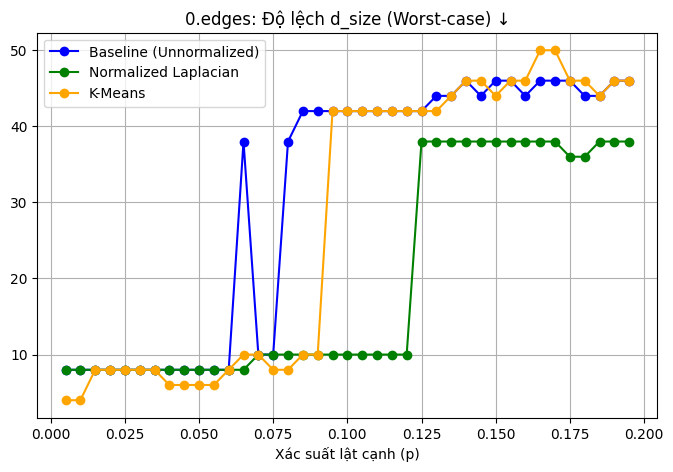

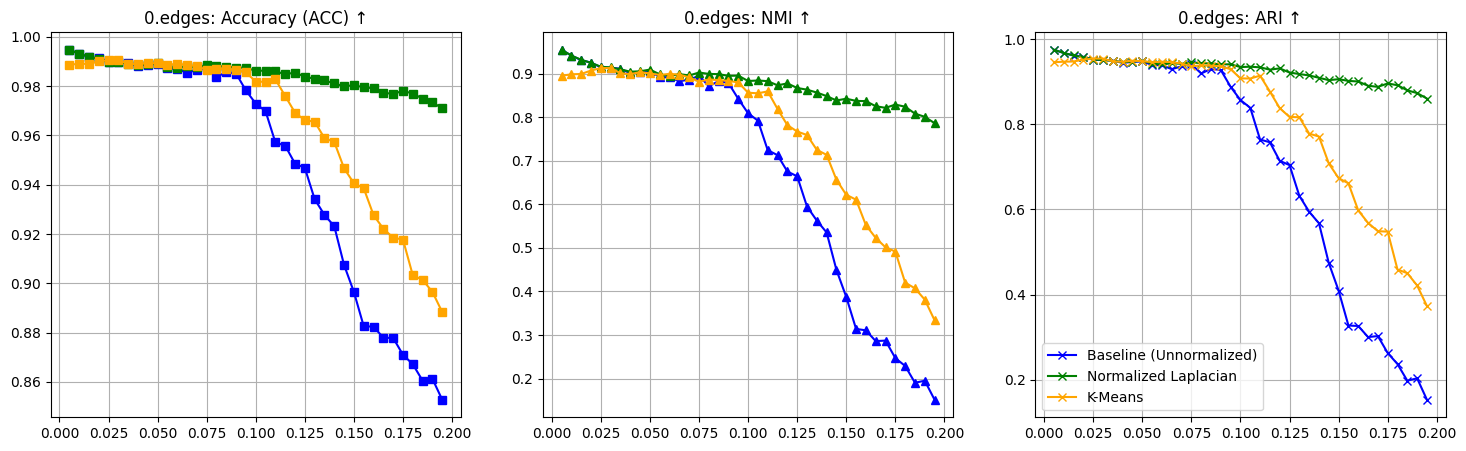

In [4]:
colors_map = {'baseline': 'blue', 'normalized': 'green', 'kmeans': 'orange'}
labels_map = {'baseline': 'Baseline (Unnormalized)', 'normalized': 'Normalized Laplacian', 'kmeans': 'K-Means'}

# Plot 1: d_size
fig1, ax1 = plt.subplots(figsize=(8, 5))
for m in results_0.keys():
    ax1.plot(probabilities_0, results_0[m]['d_size'], marker='o', label=labels_map[m], color=colors_map[m])
ax1.set_title('0.edges: Độ lệch d_size (Worst-case) ↓')
ax1.set_xlabel('Xác suất lật cạnh (p)')
ax1.legend()
ax1.grid(True)
plt.show()

# Plot 2: ML Metrics
fig2, axs = plt.subplots(1, 3, figsize=(18, 5))
for m in results_0.keys():
    axs[0].plot(probabilities_0, results_0[m]['acc'], marker='s', label=labels_map[m], color=colors_map[m])
axs[0].set_title('0.edges: Accuracy (ACC) ↑')
axs[0].grid(True)

for m in results_0.keys():
    axs[1].plot(probabilities_0, results_0[m]['nmi'], marker='^', label=labels_map[m], color=colors_map[m])
axs[1].set_title('0.edges: NMI ↑')
axs[1].grid(True)

for m in results_0.keys():
    axs[2].plot(probabilities_0, results_0[m]['ari'], marker='x', label=labels_map[m], color=colors_map[m])
axs[2].set_title('0.edges: ARI ↑')
axs[2].legend()
axs[2].grid(True)
plt.show()

## 3. Thực nghiệm Ablation trên dataset lớn (`1684.edges`)

In [5]:
print("Đang tải dữ liệu 1684.edges...")
# Đổi từ '../data/1684.edges' thành './data/1684.edges'
G_1684 = load_and_preprocess_graph('./data/1684.edges')

clean_c1_1684, clean_c2_1684, _ = spectral_clustering(G_1684)
all_nodes_1684 = list(G_1684.nodes())
y_true_1684 = get_label_array(all_nodes_1684, clean_c1_1684, clean_c2_1684)

probabilities_1684 = [i * 0.002 for i in range(1, 40)]
num_trials_1684 = 100 

results_1684 = {k: {'d_size': [], 'acc':[], 'nmi': [], 'ari': []} for k in ['baseline', 'normalized', 'kmeans']}

print("Đang chạy thực nghiệm trên 1684.edges...")
for p in tqdm(probabilities_1684):
    temp = {k: {'d_size': [], 'acc': [], 'nmi':[], 'ari':[]} for k in results_1684.keys()}
    
    for trial in range(num_trials_1684):
        G_noisy = apply_edge_flipping(G_1684, p=p, seed=GLOBAL_SEED + trial)
        
        models = {
            'baseline': spectral_clustering(G_noisy)[:2],
            'normalized': ablation_normalized_laplacian(G_noisy),
            'kmeans': ablation_kmeans(G_noisy)
        }
        
        for name, (c1, c2) in models.items():
            y_pred = get_label_array(all_nodes_1684, c1, c2)
            metrics = calculate_all_metrics(y_true_1684, y_pred)
            temp[name]['d_size'].append(symmetric_difference_distance(clean_c1_1684, clean_c2_1684, c1, c2))
            temp[name]['acc'].append(metrics['ACC'])
            temp[name]['nmi'].append(metrics['NMI'])
            temp[name]['ari'].append(metrics['ARI'])

    for name in results_1684.keys():
        results_1684[name]['d_size'].append(np.max(temp[name]['d_size']))
        results_1684[name]['acc'].append(np.mean(temp[name]['acc']))
        results_1684[name]['nmi'].append(np.mean(temp[name]['nmi']))
        results_1684[name]['ari'].append(np.mean(temp[name]['ari']))

Đang tải dữ liệu 1684.edges...
Đang chạy thực nghiệm trên 1684.edges...


100%|██████████| 39/39 [4:28:27<00:00, 413.02s/it]


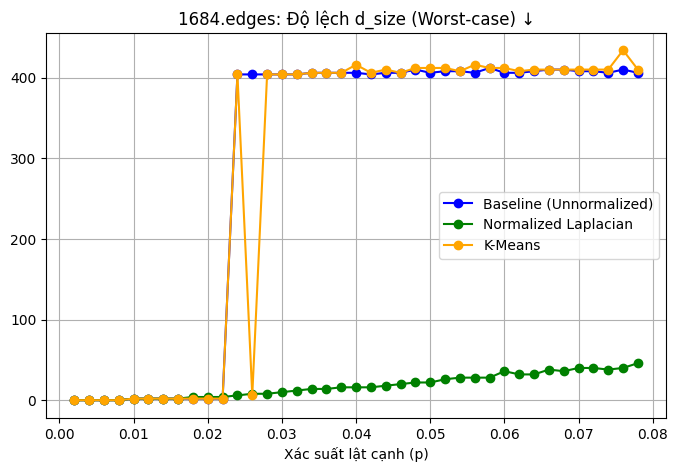

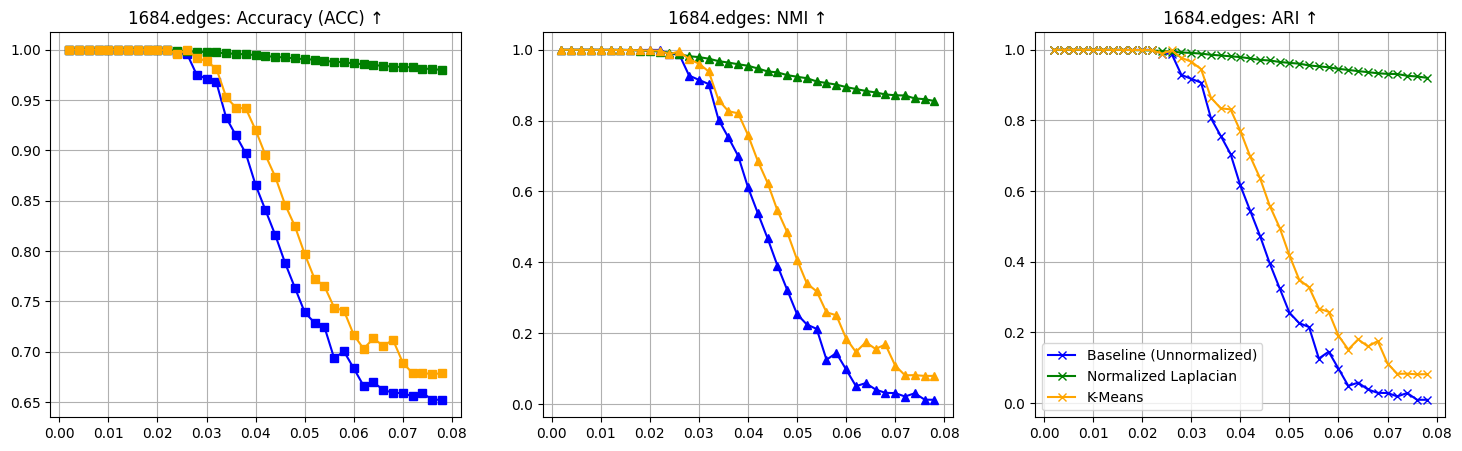

In [6]:
# Plot 1: d_size
fig3, ax3 = plt.subplots(figsize=(8, 5))
for m in results_1684.keys():
    ax3.plot(probabilities_1684, results_1684[m]['d_size'], marker='o', label=labels_map[m], color=colors_map[m])
ax3.set_title('1684.edges: Độ lệch d_size (Worst-case) ↓')
ax3.set_xlabel('Xác suất lật cạnh (p)')
ax3.legend()
ax3.grid(True)
plt.show()

# Plot 2: ML Metrics
fig4, axs = plt.subplots(1, 3, figsize=(18, 5))
for m in results_1684.keys():
    axs[0].plot(probabilities_1684, results_1684[m]['acc'], marker='s', label=labels_map[m], color=colors_map[m])
axs[0].set_title('1684.edges: Accuracy (ACC) ↑')
axs[0].grid(True)

for m in results_1684.keys():
    axs[1].plot(probabilities_1684, results_1684[m]['nmi'], marker='^', label=labels_map[m], color=colors_map[m])
axs[1].set_title('1684.edges: NMI ↑')
axs[1].grid(True)

for m in results_1684.keys():
    axs[2].plot(probabilities_1684, results_1684[m]['ari'], marker='x', label=labels_map[m], color=colors_map[m])
axs[2].set_title('1684.edges: ARI ↑')
axs[2].legend()
axs[2].grid(True)
plt.show()

## 4. Kiểm chứng việc chọn Vector riêng
Cố tình chọn sai Vector riêng (v3, v4) thay vì v2 để chứng minh sự thất bại toán học của thuật toán.

Đang chạy Thực nghiệm chọn Vector...


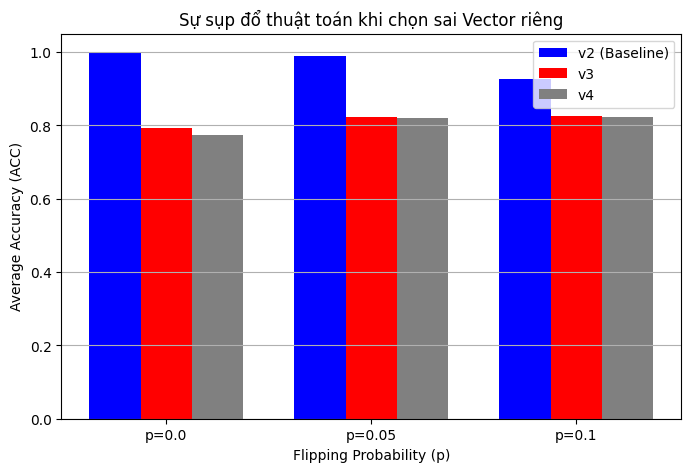

In [7]:
p_test =[0.0, 0.05, 0.1]
num_trials_vectors = 5
vectors = {'v2 (Baseline)': 1, 'v3 (Ablation)': 2, 'v4 (Ablation)': 3}

results_vectors = {name: {'acc':[]} for name in vectors.keys()}

print("Đang chạy Thực nghiệm chọn Vector...")
for p in p_test:
    temp_v = {name:[] for name in vectors.keys()}
    for trial in range(num_trials_vectors):
        G_noisy = apply_edge_flipping(G_0, p=p, seed=GLOBAL_SEED + trial)
        for name, idx in vectors.items():
            c1, c2 = ablation_custom_eigenvector(G_noisy, idx)
            y_pred = get_label_array(all_nodes_0, c1, c2)
            metrics = calculate_all_metrics(y_true_0, y_pred)
            temp_v[name].append(metrics['ACC'])
            
    for name in vectors.keys():
        results_vectors[name]['acc'].append(np.mean(temp_v[name]))

# Vẽ Bar Chart
x = np.arange(len(p_test))
width = 0.25

fig5, ax5 = plt.subplots(figsize=(8, 5))
ax5.bar(x - width, results_vectors['v2 (Baseline)']['acc'], width, label='v2 (Baseline)', color='blue')
ax5.bar(x, results_vectors['v3 (Ablation)']['acc'], width, label='v3', color='red')
ax5.bar(x + width, results_vectors['v4 (Ablation)']['acc'], width, label='v4', color='grey')

ax5.set_ylabel('Average Accuracy (ACC)')
ax5.set_xlabel('Flipping Probability (p)')
ax5.set_title('Sự sụp đổ thuật toán khi chọn sai Vector riêng')
ax5.set_xticks(x)
ax5.set_xticklabels([f"p={p}" for p in p_test])
ax5.legend()
ax5.grid(axis='y')
plt.show()